In [1]:
import xarray as xr
import sys 
import os
os.chdir("../")
import lightning as L
from pytorch_lightning.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
# from src.models.models import SimpleMLP
# from src.data.datamodule import CustomDataModule
from src.models.lightning_module import RainfallRegressionModel
from src.data.datamodule import MyDataModule
from src.utils.config import load_config
from src.data.transforms import StandardScalerX,MinMaxScalerY
import argparse
import os
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from src.data.dataset import AtmosphereToRainfallDataset

config = load_config('./configs/experiments/default.yml')

datamodule = MyDataModule(data_in_name=config['data']["data_in_name"],
                          data_target_name=config['data']["data_target_name"],
                          batch_size=config['data']["batch_size"],
                          transform_X=StandardScalerX(),
                          transform_y=MinMaxScalerY())
datamodule.setup()
loader = datamodule.train_dataloader()
X = next(iter(loader))['x']

In [3]:
from src.models.models import TwoLayerCNN
NN = TwoLayerCNN(input_size=1, hidden_size=64, target_size=1)
NN

/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


TwoLayerCNN(
  (relu): ReLU()
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=0, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:

from torch import nn

NN = TwoLayerCNN(input_size=1, n_kernels=12, target_size=1, image_size = datamodule.image_size)
NN(X)

torch.Size([32, 1, 32, 32])
torch.Size([32, 12, 16, 16])
torch.Size([32, 24, 8, 8])
torch.Size([32, 1536])


tensor([[ 3.9927e-02],
        [-1.8798e-02],
        [ 1.2688e-02],
        [-1.3113e-02],
        [-1.2686e-02],
        [ 2.8656e-02],
        [-9.4642e-03],
        [ 1.2374e-02],
        [ 1.1151e-02],
        [-1.6162e-02],
        [-2.7514e-02],
        [ 4.0191e-02],
        [ 1.2400e-02],
        [ 3.6287e-03],
        [-2.8362e-03],
        [ 1.1813e-02],
        [-1.0316e-02],
        [ 2.5338e-02],
        [ 3.2740e-02],
        [ 1.9448e-02],
        [ 1.1937e-02],
        [-4.1113e-03],
        [ 2.5122e-02],
        [ 5.6278e-03],
        [ 2.0550e-03],
        [ 3.1312e-02],
        [-3.1497e-02],
        [ 1.1940e-02],
        [-1.6883e-05],
        [ 2.7425e-02],
        [ 9.2707e-03],
        [ 1.3082e-02]], grad_fn=<AddmmBackward0>)

In [17]:
NN.linear_input_size

1536

In [15]:
6*8*8

384

In [7]:
NN(X)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x4096 and 0x64)

In [5]:
datamodule.image_size

1024

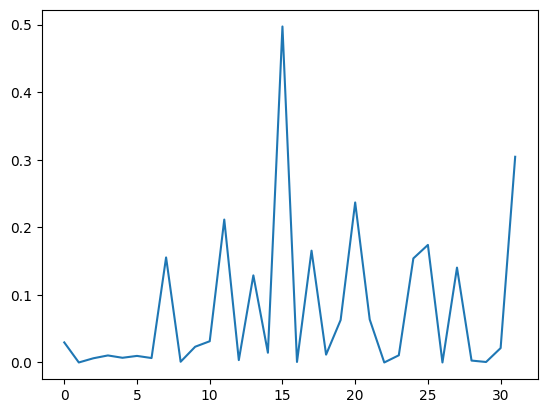

In [5]:
plt.plot(next(iter(datamodule.train_dataloader()))['y'])

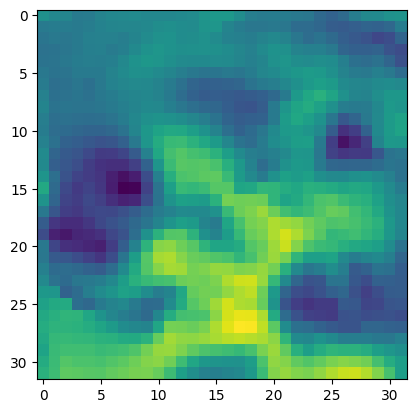

In [29]:
plt.imshow(next(iter(datamodule.train_dataloader()))['x'][5])

In [28]:
import numpy as np
np.prod(datamodule.image_shape[-2:])

np.int64(1024)

In [6]:
datamodule.transform_X.fitted

True

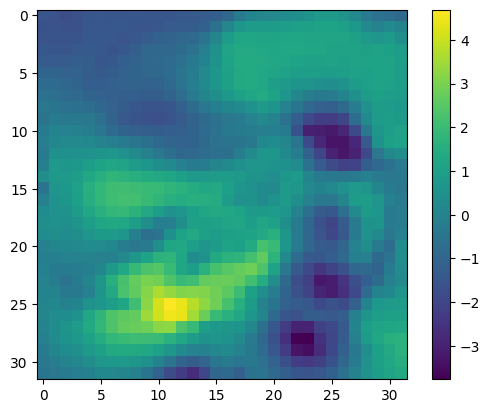

In [15]:
plt.imshow(datamodule.dataset_train[0]['x'])
plt.colorbar()

In [9]:
data_in_name = config['data']['data_in_name']
data_target_name = config['data']['data_target_name']

val_dataset = AtmosphereToRainfallDataset(data_in_name, data_target_name, time_slice=('2006','2014'))
test_dataset = AtmosphereToRainfallDataset(data_in_name, data_target_name, time_slice=('2015','2024'))


In [29]:
train_dataset.ds.argmax('time')

<xarray.Dataset> Size: 17kB
Dimensions:     (x: 32, y: 32)
Coordinates:
  * x           (x) float64 256B -9.823e+06 -9.35e+06 ... 4.35e+06 4.823e+06
    lat         (y, x) float32 4kB -6.86 -5.481 -4.103 ... 36.87 34.62 32.27
    lon         (y, x) float32 4kB -45.0 -43.59 -42.11 ... 141.2 137.9 135.0
  * y           (y) float64 256B -9.823e+06 -9.35e+06 ... 4.35e+06 4.823e+06
Data variables:
    predictors  (y, x) int64 8kB 4611 4611 2747 2746 ... 2266 5087 6988 5831
    targets     int64 8B 9814

In [ ]:
train_dataset = AtmosphereToRainfallDataset(data_in_name, 
                                           data_out_name, 
                                           time_slice=('1979','2005'))
train_dataset[9814]

{'x': tensor([[100965.2656, 100892.2031, 100837.4375,  ..., 100945.4844,
          100991.5469, 100917.8828],
         [100930.4688, 100856.2188, 100857.4766,  ..., 101024.5625,
          101010.1562, 100893.0234],
         [100867.3281, 100852.9922, 100864.2344,  ..., 101353.0703,
          101214.1797, 101034.1250],
         ...,
         [101148.6719, 101165.9531, 101231.1797,  ..., 101952.5312,
          102118.9375, 102124.6250],
         [101121.8906, 101134.6641, 101199.2656,  ..., 101806.7344,
          101755.6406, 101648.6172],
         [101101.4688, 101104.3750, 101152.1797,  ..., 101550.1875,
          101372.9141, 101318.1016]]),
 'y': tensor(85.2317),
 'idx': 9814}

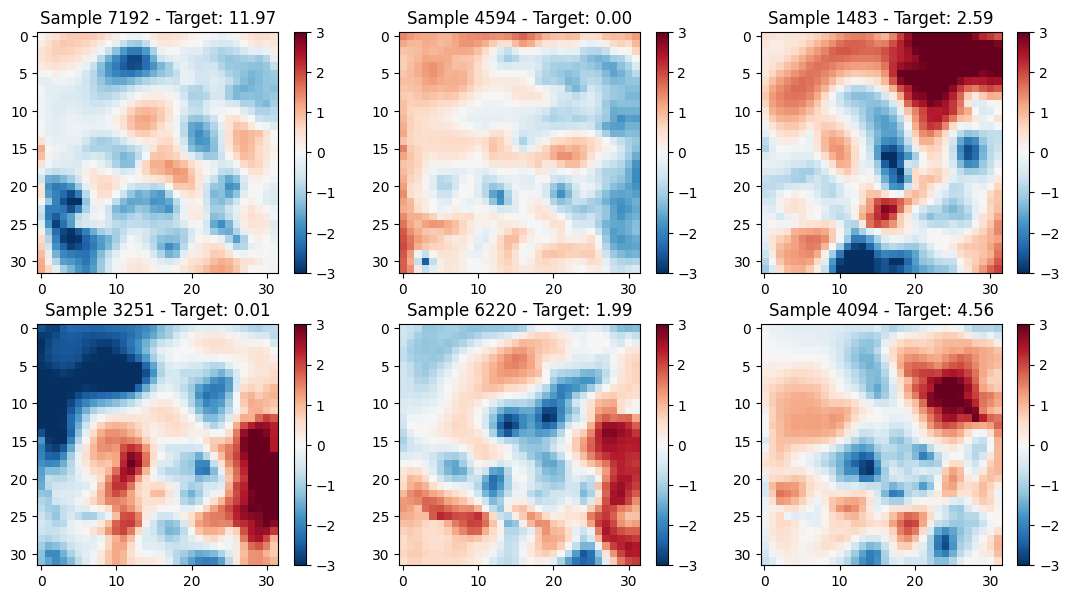

In [63]:
import numpy as np
fig, axs = plt.subplots(2, 3, figsize=(11, 6))
for k,i in enumerate(np.random.choice(len(train_dataset), size=6, replace=False)):
    sample = train_dataset[i]
    plot = axs.flat[k].imshow(sample['x'],cmap='RdBu_r', vmax=3, vmin=-3)
    plt.colorbar(plot)
    axs.flat[k].set_title(f"Sample {i} - Target: {sample['y'].item():.2f}")

plt.tight_layout()

In [65]:
from torch.utils.data import DataLoader
dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)

In [ ]:
for batch in dataloader:
    x = batch["x"]
    y = batch["y"]

{'x': tensor([[[-0.8635, -0.9242, -0.8431,  ..., -0.2077, -0.1880, -0.3115],
         [-0.9058, -0.9530, -0.9334,  ..., -0.8919, -0.8505, -0.6596],
         [-0.8744, -0.9014, -0.9451,  ..., -1.0379, -0.9670, -0.9580],
         ...,
         [-1.0175, -0.6701, -0.3208,  ...,  0.1156,  0.4066,  0.2707],
         [-1.0242, -0.7223, -0.2636,  ...,  0.0698,  0.3676,  0.1766],
         [-0.9714, -0.7750, -0.4070,  ...,  0.0950,  0.1876,  0.1915]],

        [[-1.1257, -1.1028, -1.1098,  ..., -2.0821, -2.1083, -1.9222],
         [-1.0555, -1.0401, -1.2288,  ..., -2.0358, -1.9920, -2.0253],
         [-0.8930, -0.9813, -1.3050,  ..., -1.3522, -1.3524, -1.8091],
         ...,
         [-1.0476, -0.6424, -0.1447,  ...,  0.9005,  1.3718,  1.4531],
         [-1.0651, -0.7811, -0.1751,  ...,  1.2832,  1.6210,  1.5251],
         [-1.1005, -0.8793, -0.3343,  ...,  1.2712,  1.3293,  1.3424]],

        [[ 0.2359,  0.1590,  0.1322,  ...,  0.3624,  0.3713,  0.3941],
         [-0.0231, -0.0413, -0.1131,  .

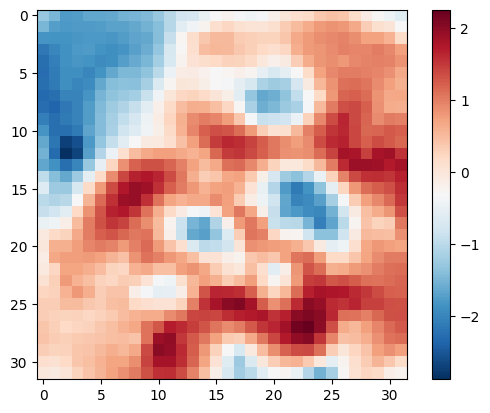

In [ ]:
plt.imshow(train_dataset[9814]['x'],cmap='RdBu_r')
plt.colorbar()

train_dataset[9814]['x']

In [ ]:
from src.data.transforms import StandardScalerX

scaler = StandardScalerX()
scaler.fit(train_dataset)
train_dataset.transform_X = scaler

In [ ]:
train_dataset

In [9]:
from src.data.transforms import StandardScalerX

scaler = StandardScalerX()
scaler.fit(train_dataset)
train_dataset.transform_X = scaler
val_dataset.transform_X = scaler
test_dataset.transform_X = scaler

In [19]:
test_dataset.times[test_dataset[1245]['idx']]

np.datetime64('2018-05-30T00:00:00.000000000')

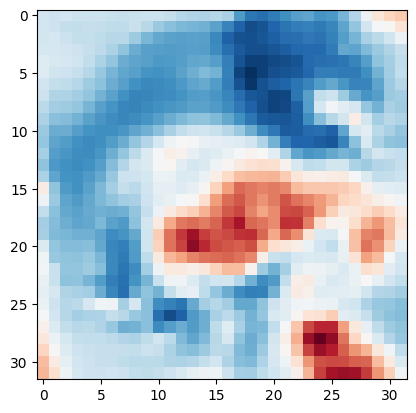

In [11]:
plt.imshow(test_dataset[0]['x'], vmin=-3, vmax=3, cmap='RdBu')

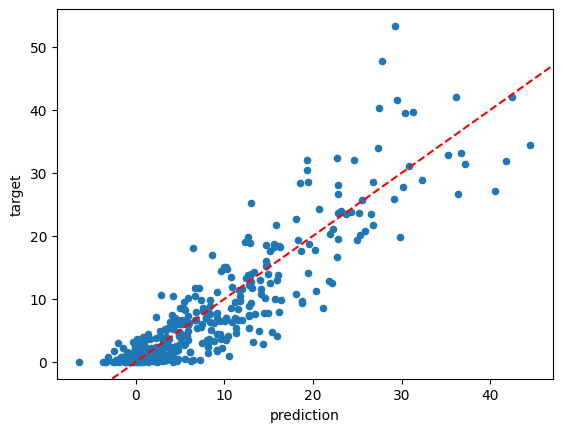

In [6]:
df = pd.read_csv("/Users/robin/Library/CloudStorage/OneDrive-UniversityofBergen/Documents/Travail/Cours/2026 - ML BCCR Course/course_git/BCCR-ml-project-example/outputs/bccr-ml-course/iprziwi7/predictions.csv", index_col=0, parse_dates=True)

df.query("data_slice == 'test'").plot(x='prediction', y='target', kind='scatter')
plt.axline((0,0), slope=1, color='red', linestyle='--')

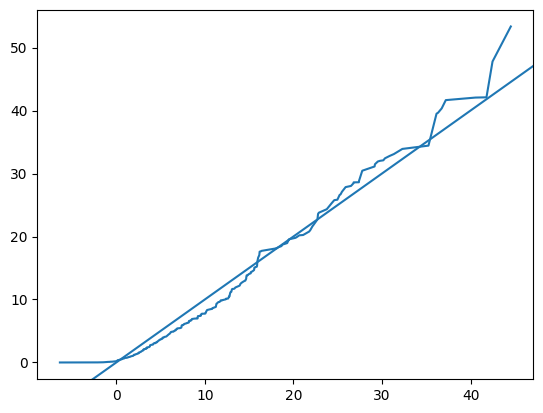

In [22]:
# plt.plot(df.query("data_slice == 'test'").sort_values('target').target.values)
plt.plot(df.query("data_slice == 'test'").sort_values('prediction').prediction.values, df.query("data_slice == 'test'").sort_values('target').target.values)
plt.axline((0,0) ,slope=1)

In [2]:
config = load_config('configs/experiments/default.yml')

wandb_logger = WandbLogger(
    project=config['logging']['project'],
    name=config['logging'].get('run_name'),
    config=config,
    save_dir=config['logging']['base_dir']
)

run_id = wandb_logger.experiment.id
out_dir = f"{config['logging']['base_dir']}/{config['logging']['project']}/{run_id}"

datamodule = CustomDataModule(
    data_in_path=config['data']['input_path'],
    data_target_path=config['data']['target_path'],
    batch_size=config['data']['batch_size']
)

image_size = datamodule.image_shape[1]*datamodule.image_shape[2]

model = SimpleMLP(input_size=image_size, 
                    hidden_size=config['model']['hidden_size'], 
                    target_size=1)

lightning_model = RainfallRegressionModel(model, learning_rate=config['trainer']['learning_rate'])

checkpoint_callback = ModelCheckpoint(
    dirpath=os.path.join(out_dir, "checkpoints"),
    filename="best",
    monitor="val_loss",
    save_top_k=1,
    mode="min",
)

trainer = L.Trainer(
    max_epochs=config['trainer']['max_epochs'],
    logger=wandb_logger,
    default_root_dir=out_dir,
    callbacks=[checkpoint_callback],
)

trainer.fit(lightning_model, datamodule=datamodule)
trainer.validate(lightning_model, datamodule=datamodule)




wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/robin/.netrc.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type      | Params | Mode  | FLOPs
--------------------------------------------------------
0 | model     | SimpleMLP | 262 K  | train | 0    
1 | criterion | MSELoss   | 0      | train | 0    
--------------------------------------------------------
262 K     Trainable params
0         Non-trainable params
262 K     Total params
1.049     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode
0         Total Flops


/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the 

Epoch 19: 100%|██████████| 93/93 [00:00<00:00, 107.45it/s, v_num=fojg, val_loss=24.30, val_r2=0.723]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 93/93 [00:00<00:00, 106.43it/s, v_num=fojg, val_loss=24.30, val_r2=0.723]


/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Validation DataLoader 0: 100%|██████████| 12/12 [00:00<00:00, 149.13it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        val_loss            24.308313369750977
         val_r2             0.7233645915985107
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val_loss': 24.308313369750977, 'val_r2': 0.7233645915985107}]

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


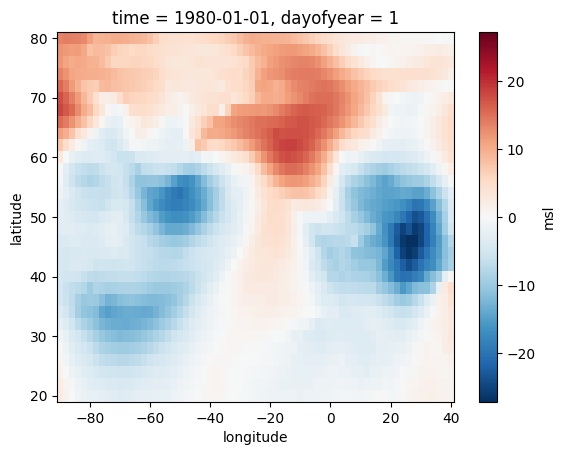

In [ ]:
ds = xr.open_dataset(config['data']['input_path'])

ds.msl.isel(time=0).plot()

In [23]:
all_predictions = []
all_targets = []
for prediction, target in trainer.predict(lightning_model, datamodule=datamodule):
    all_predictions.append(prediction)
    all_targets.append(target)
predictions = torch.cat(all_predictions, dim=0)
targets = torch.cat(all_targets, dim=0)

/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 12/12 [00:00<00:00, 142.39it/s]


In [24]:
plt.plot(targets)

NameError: name 'plt' is not defined

In [3]:
import torch
predictions = torch.cat(trainer.predict(lightning_model, datamodule=datamodule), dim=0)
predictions

/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/bccr-ml-project/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 12/12 [00:00<00:00, 118.03it/s]


TypeError: expected Tensor as element 0 in argument 0, but got tuple

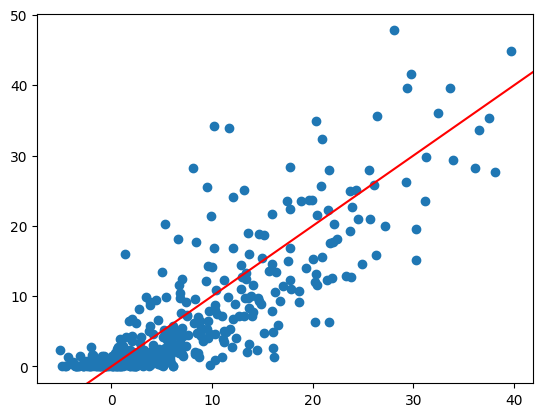

In [30]:
import matplotlib.pyplot as plt
plt.scatter(predictions, targets)
plt.axline((0,0),(1,1), color='red')


In [ ]:
from src.models.models import SimpleMLP
from src.data.dataset import CustomDataset
from src.data.datamodule import CustomDataModule
from src.models.lightning_module import RainfallRegressionModel
from src.utils.config import load_config

In [18]:
load_config('../configs/experiments/default.yml')

{'model': {'input_channels': 1, 'hidden_size': 128},
 'data': {'input_path': 'data/raw/msl_data_northatlantic.nc',
  'target_path': 'data/raw/pr_era5_daily_westnorway_1940-2024.nc',
  'batch_size': 128,
  'num_workers': 4},
 'trainer': {'max_epochs': 50,
  'learning_rate': 0.001,
  'accelerator': 'gpu',
  'devices': 1},
 'logging': {'project': 'extreme-rainfall', 'run_name': 'baseline'}}

In [3]:
datamodule = CustomDataModule(
    data_in_path="../data/raw/msl_data_northatlantic.nc",
    data_out_path="../data/raw/pr_era5_daily_westnorway_1940-2024.nc",
    batch_size=128)

In [4]:
dataset = CustomDataset(
    ds_in_path="../data/raw/msl_data_northatlantic.nc",
    ds_out_path="../data/raw/pr_era5_daily_westnorway_1940-2024.nc",)

In [ ]:
model = SimpleMLP(input_size=datamodule.image_shape[1]*datamodule.image_shape[2], hidden_size=64, output_size=1)
lightning_model = RainfallRegressionModel(model, learning_rate=1e-3)
trainer = L.Trainer(max_epochs=20)
lightning_model.train()
trainer.fit(lightning_model, datamodule=datamodule)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type      | Params | Mode  | FLOPs
--------------------------------------------------------
0 | model     | SimpleMLP | 131 K  | train | 0    
1 | criterion | MSELoss   | 0      | train | 0    
--------------------------------------------------------
131 K     Trainable params
0         Non-trainable params
131 K     Total params
0.524     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (24) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [9]:
trainer.validate(lightning_model, datamodule=datamodule)

/opt/anaconda3/envs/bccr-ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        val_loss             31.75809669494629
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val_loss': 31.75809669494629}]